## Loading the data and other imports

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle
import joblib
from scipy.stats import chi2_contingency

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [8]:
df = pd.read_csv('hypertension_dataset.csv')

## Exploratory Data Analysis

In [9]:
df.shape

(1985, 11)

In [10]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [11]:
df.tail()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No
1984,38,7.3,0,Normal,8.3,18.6,NaN,Yes,Low,Smoker,No


In [12]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

In [13]:
cl = ['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension']

In [14]:
for i in cl:
    print(f'{i}: {df[i].unique()}')

Age: [69 32 78 38 41 20 39 70 19 47 55 81 77 50 75 66 76 59 79 64 68 72 24 56
 35 21 31 26 61 25 52 53 67 23 71 80 51 65 57 43 58 46 62 82 18 28 22 45
 29 40 54 44 60 30 49 83 74 73 36 34 33 37 84 48 42 63 27]
Salt_Intake: [ 8.  11.7  9.5 10.   9.8 10.8  8.9  5.9  9.3  7.2  7.4  9.7 11.   8.5
  9.1 11.9  9.  13.7  9.6  5.  11.1  8.2  6.1  8.1  6.8  7.3 11.8  9.4
 10.9  6.9  8.3  6.7  7.6  9.9  7.8 12.   7.7 10.4  5.7  5.4 13.6 11.6
 12.5 12.6 10.5 10.1  8.7 11.5  6.2  7.1  4.8  6.5 12.2  6.6 10.7 12.3
  7.5  6.3  8.8  5.3  2.8  8.4  9.2 10.3  7.   3.7  7.9  8.6  6.   5.8
  6.4  2.7  3.8 11.2 14.9  5.6 10.2 10.6 11.3  4.3 12.4  4.2  3.1 12.8
  5.5  4.7  4.9 12.1  5.2  5.1 13.   4.5  3.4 13.8 14.8  2.6  2.5 14.
  3.6  3.9 11.4 13.3 12.7  4.1  4.6  3.3 14.7 13.2 14.4 14.5 13.4  3.2
  4.  13.9 12.9  3.  16.4  3.5  4.4 13.1 14.2]
Stress_Score: [ 9 10  3  1  0  7  5  8  6  4  2]
BP_History: ['Normal' 'Hypertension' 'Prehypertension']
Sleep_Duration: [ 6.4  5.4  7.1  4.2  5.8  5.2  7.8  7.2  

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


In [16]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

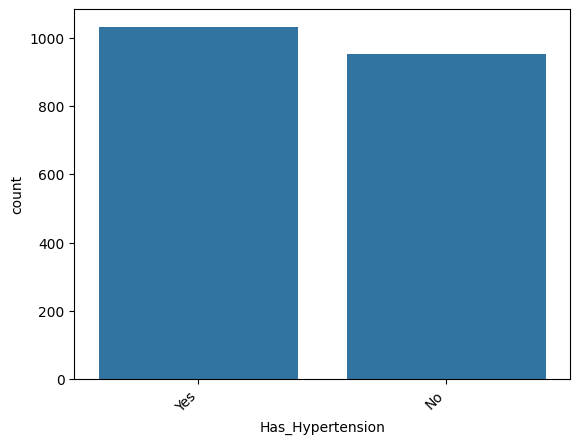

In [17]:
sns.countplot(x='Has_Hypertension',data=df)
plt.xticks(rotation=45, ha='right')

In [18]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

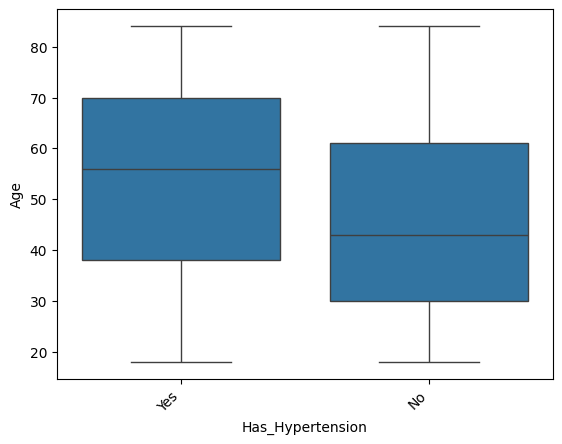

In [19]:
sns.boxplot(x='Has_Hypertension',y='Age',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

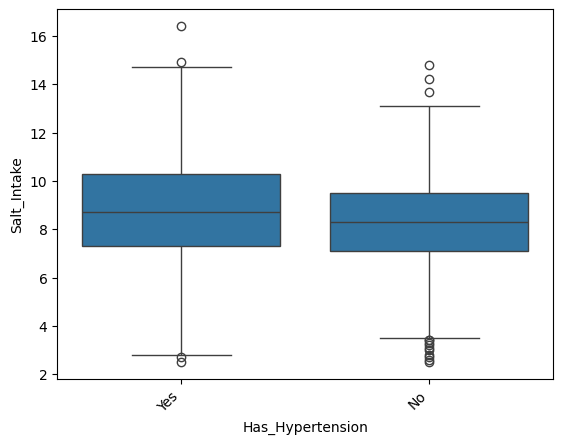

In [20]:
sns.boxplot(x='Has_Hypertension',y='Salt_Intake',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

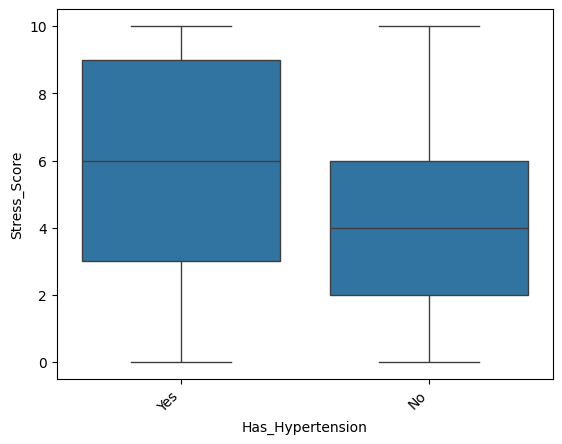

In [21]:
sns.boxplot(x='Has_Hypertension',y='Stress_Score',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

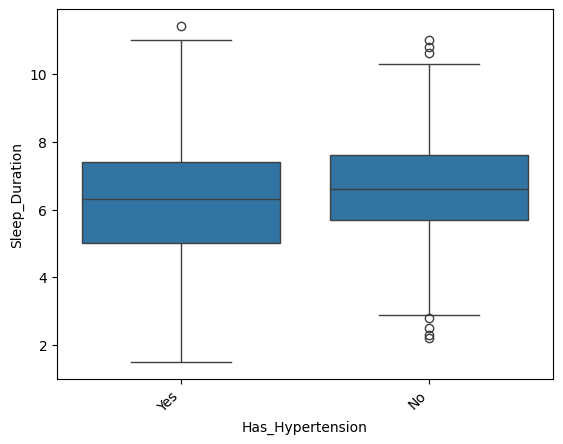

In [22]:
sns.boxplot(x='Has_Hypertension',y='Sleep_Duration',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

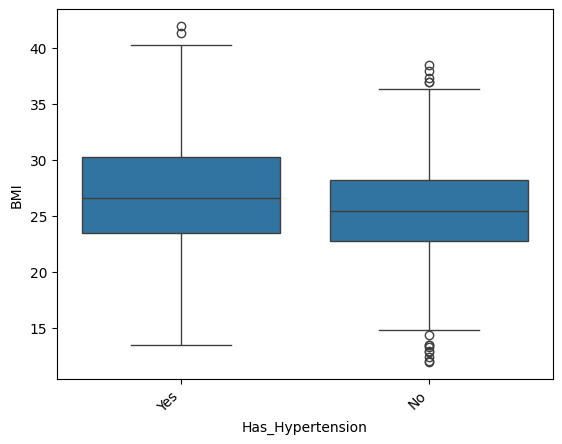

In [23]:
sns.boxplot(x='Has_Hypertension',y='BMI',data=df)
plt.xticks(rotation=45, ha='right')

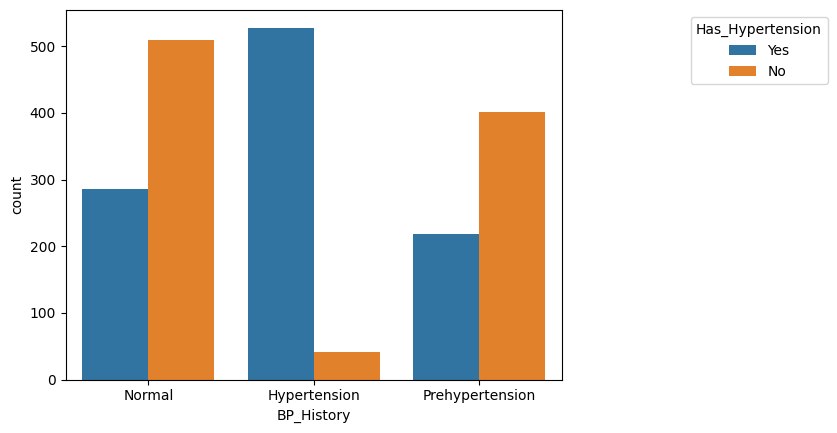

In [24]:
sns.countplot(x='BP_History',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

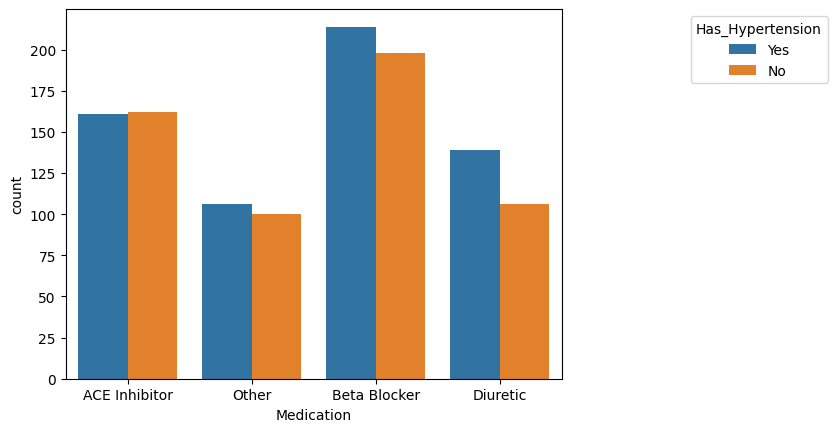

In [25]:
sns.countplot(x='Medication',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

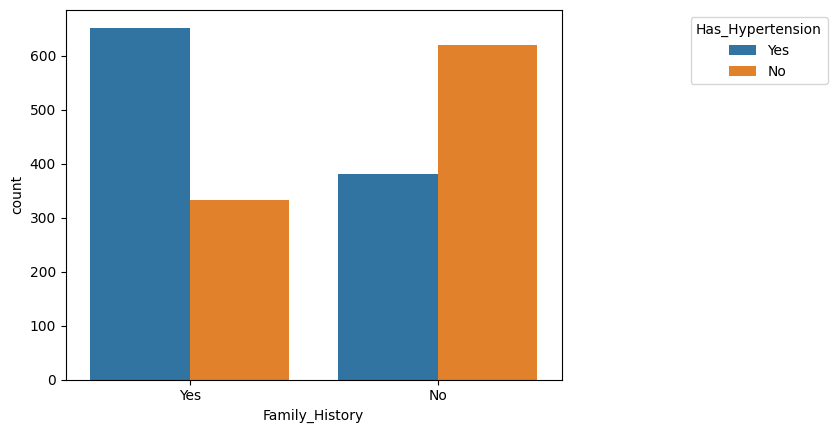

In [26]:
sns.countplot(x='Family_History',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

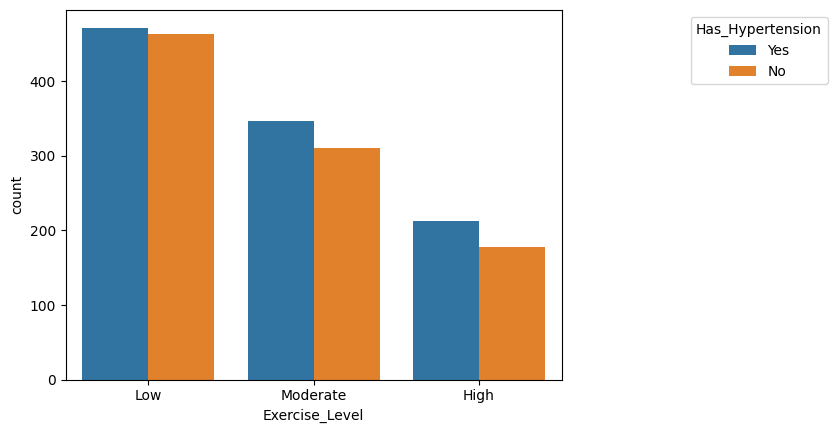

In [27]:
sns.countplot(x='Exercise_Level',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

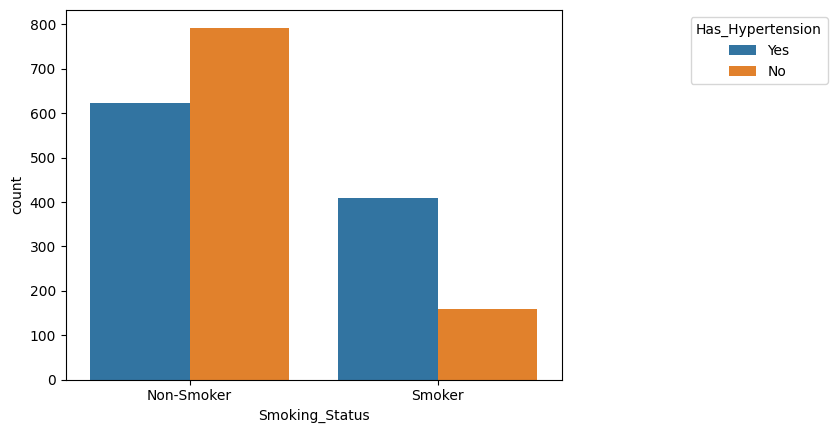

In [28]:
sns.countplot(x='Smoking_Status',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

### analyze the association between each independent variable and the Category

#### categorical features and Category

In [29]:
categorical_features =list(df.select_dtypes(['object']).columns)[:-1]
categorical_features

['BP_History',
 'Medication',
 'Family_History',
 'Exercise_Level',
 'Smoking_Status']

In [30]:
def cramers_v_and_p(matrix):
    chi2, p, _, _ = chi2_contingency(matrix)
    n = matrix.sum().sum()
    r, k = matrix.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return cramers_v, p

In [31]:
results = []

for features in categorical_features:

    matrix = pd.crosstab(df[features], df['Has_Hypertension'])
    
    cv, p_value = cramers_v_and_p(matrix)
    results.append((features, cv, p_value))

In [32]:
results_df = pd.DataFrame(results, columns=['categorical features', 'Cramér\'s V', 'p-value'])

In [33]:
results_df['Significant'] = results_df['p-value'] < 0.05

In [34]:
results_df

,categorical features,Cramér's V,p-value,Significant
0,BP_History,0.517774,2.776075e-116,True
1,Medication,0.048513,4.249486e-01,False
2,Family_History,0.281136,5.411556e-36,True
3,Exercise_Level,0.031980,3.623828e-01,False
4,Smoking_Status,0.250321,6.951639e-29,True


removing unnecessary columns

In [35]:
df.drop(['Medication', "Exercise_Level"], axis=1, inplace=True)

In [36]:
categorical_features =list(df.select_dtypes(['object']).columns)[:-1]
categorical_features

['BP_History', 'Family_History', 'Smoking_Status']

#### Numerical features and Category

In [37]:
le = LabelEncoder()
df['Category Encoded'] = le.fit_transform(df['Has_Hypertension'])

In [38]:
corr_for_numerical = df.drop(categorical_features + ["Has_Hypertension"], axis=1).corr()
corr_for_numerical

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,Category Encoded
Age,1.000000,0.011205,-0.032184,-0.011839,-0.023498,0.210677
Salt_Intake,0.011205,1.000000,0.008129,0.020394,0.039530,0.114415
Stress_Score,-0.032184,0.008129,1.000000,0.021191,0.011450,0.186910
Sleep_Duration,-0.011839,0.020394,0.021191,1.000000,0.025476,-0.119561
BMI,-0.023498,0.039530,0.011450,0.025476,1.000000,0.145093
Category Encoded,0.210677,0.114415,0.186910,-0.119561,0.145093,1.000000


In [39]:
corr_for_numerical["Category Encoded"]

Age                 0.210677
Salt_Intake         0.114415
Stress_Score        0.186910
Sleep_Duration     -0.119561
BMI                 0.145093
Category Encoded    1.000000
Name: Category Encoded, dtype: float64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Salt_Intake'),
  Text(2, 0, 'Stress_Score'),
  Text(3, 0, 'Sleep_Duration'),
  Text(4, 0, 'BMI'),
  Text(5, 0, 'Category Encoded')])

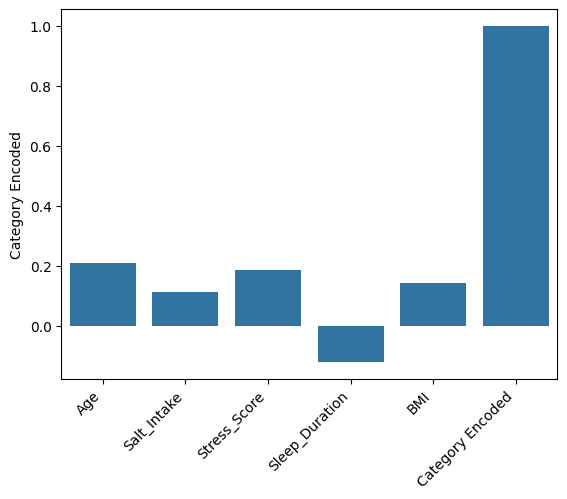

In [40]:
sns.barplot( data=corr_for_numerical["Category Encoded"] )
plt.xticks(rotation=45, ha='right')

In [41]:
df.drop("Category Encoded", axis=1, inplace=True)

In [42]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Family_History', 'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

## Data PreProcessing

In [43]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Family_History,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,Yes,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,No,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,No,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,No,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,No,Non-Smoker,No


In [44]:
df.isnull().sum()

Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Family_History      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

#### split dataset into training and testing sets

In [45]:
X = df.drop("Has_Hypertension", axis=1)
y = df["Has_Hypertension"]

#### Categorical Variables Handling

In [46]:
cat_features = list(X.select_dtypes(['object']).columns)
cat_features

['BP_History', 'Family_History', 'Smoking_Status']

In [47]:
preprocessor = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), cat_features)],
    remainder='passthrough')

In [48]:
X = preprocessor.fit_transform(X)

In [49]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

#### Train Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Models Training 

In [51]:
df["Has_Hypertension"].unique()

array(['Yes', 'No'], dtype=object)

In [52]:
classes = ['Yes', 'No']

def plot_confusion_matrix(y_true, y_pred, classes, figsize=(6, 4), cmap=plt.cm.Blues):

    cm = confusion_matrix(y_true, y_pred) 
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, cmap=cmap, fmt=".2f", xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

### SVM

In [53]:
svm_classifier = SVC(kernel='linear')

In [54]:
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [55]:
y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("SVM_Accuracy:", accuracy*100)

print(classification_report(y_test, y_pred))

SVM_Accuracy: 87.75167785234899
              precision    recall  f1-score   support

          No       0.87      0.87      0.87       287
         Yes       0.88      0.88      0.88       309

    accuracy                           0.88       596
   macro avg       0.88      0.88      0.88       596
weighted avg       0.88      0.88      0.88       596



In [56]:
y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("SVM_Accuracy:", accuracy*100)

print(classification_report(y_test, y_pred))

SVM_Accuracy: 87.75167785234899
              precision    recall  f1-score   support

          No       0.87      0.87      0.87       287
         Yes       0.88      0.88      0.88       309

    accuracy                           0.88       596
   macro avg       0.88      0.88      0.88       596
weighted avg       0.88      0.88      0.88       596



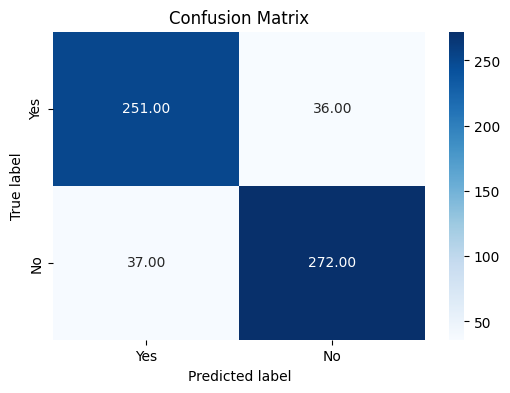

In [57]:
plot_confusion_matrix(y_test, y_pred, classes)

### KNN

In [58]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [59]:
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [60]:
y_pred_knn = knn_classifier.predict(X_test)

In [61]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn*100)


print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 69.46308724832215
              precision    recall  f1-score   support

          No       0.66      0.75      0.70       287
         Yes       0.73      0.65      0.69       309

    accuracy                           0.69       596
   macro avg       0.70      0.70      0.69       596
weighted avg       0.70      0.69      0.69       596



In [62]:
confusion_matrix(y_test,y_pred_knn)

array([[214,  73],
       [109, 200]])

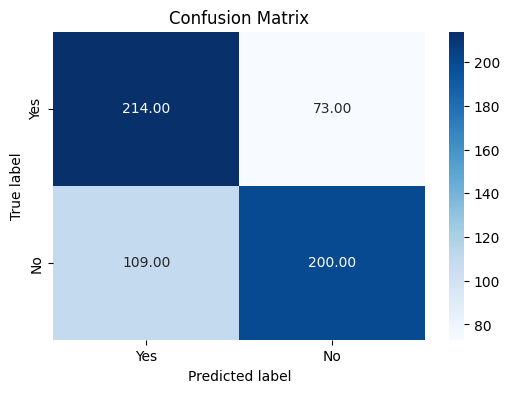

In [63]:
plot_confusion_matrix(y_test, y_pred_knn, classes)

## MLPClassifier

In [64]:
mlp_classifier = MLPClassifier()

In [65]:
mlp_classifier.fit(X_train, y_train)

d:\SLIIT\Y4.S1\Research\Hypertention_Risk_Prediction\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

In [66]:
y_pred_mlp = mlp_classifier.predict(X_test)

In [67]:
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print("MLPClassifier Accuracy:", accuracy_mlp*100)

print(classification_report(y_test, y_pred_mlp))

MLPClassifier Accuracy: 89.42953020134227
              precision    recall  f1-score   support

          No       0.86      0.93      0.89       287
         Yes       0.93      0.86      0.89       309

    accuracy                           0.89       596
   macro avg       0.90      0.90      0.89       596
weighted avg       0.90      0.89      0.89       596



In [68]:
confusion_matrix(y_test,y_pred_mlp)

array([[268,  19],
       [ 44, 265]])

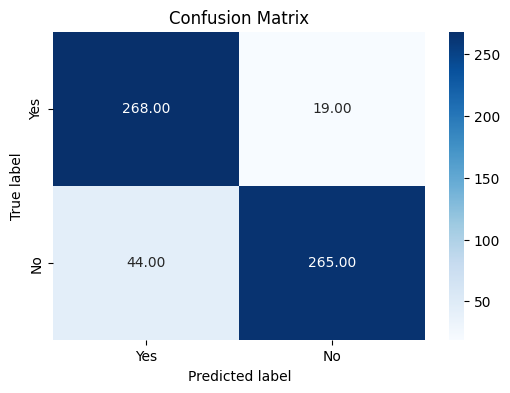

In [69]:
plot_confusion_matrix(y_test, y_pred_mlp, classes)

## Random Forest Classifier

In [70]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [71]:
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [72]:
y_pred_rf = rf_classifier.predict(X_test)

In [73]:
accuracy_mlp = accuracy_score(y_test, y_pred_rf)
print("RF_Classifier Accuracy:", accuracy_mlp*100)

print(classification_report(y_test, y_pred_rf))

RF_Classifier Accuracy: 95.30201342281879
              precision    recall  f1-score   support

          No       0.94      0.97      0.95       287
         Yes       0.97      0.94      0.95       309

    accuracy                           0.95       596
   macro avg       0.95      0.95      0.95       596
weighted avg       0.95      0.95      0.95       596



In [74]:
confusion_matrix(y_test,y_pred_rf)

array([[278,   9],
       [ 19, 290]])

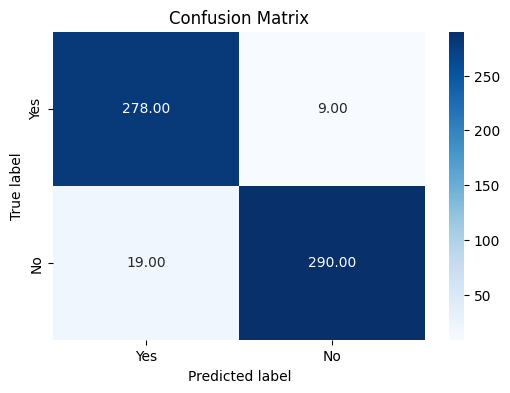

In [75]:
plot_confusion_matrix(y_test, y_pred_rf, classes)

## Save Best Model

In [76]:
# with open('RF_model.pkl', 'wb') as file:
#     pickle.dump(rf_classifier, file)

## check predictions

In [77]:
with open('RF_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [78]:
loaded_preprocessor = joblib.load('preprocessor.pkl')

In [79]:
for i in cat_features:
    print(f'{i}: {df[i].unique()}')

BP_History: ['Normal' 'Hypertension' 'Prehypertension']
Family_History: ['Yes' 'No']
Smoking_Status: ['Non-Smoker' 'Smoker']


In [80]:
def get_prediction(df):
    x =loaded_preprocessor.transform(df) 
    y_pred = loaded_model.predict(x)
    # print(y_pred[0])
    return y_pred[0]

In [81]:
df.head(5)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Family_History,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,Yes,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,No,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,No,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,No,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,No,Non-Smoker,No


In [82]:
dict_sample1 = {
    'Age': 69,
    'Salt_Intake': 8,
    'Stress_Score': 9,
    'BP_History': 'Normal',
    'Sleep_Duration': 6.4,
    'BMI': 25.8,
    'Family_History': 'Yes',
    'Smoking_Status': 'Non-Smoker'
}
sample1 = pd.DataFrame([dict_sample1])
get_prediction(sample1)

'Yes'

In [83]:
dict_sample2 = {
    'Age': 32,
    'Salt_Intake': 11.7,
    'Stress_Score': 10,
    'BP_History': 'Normal',
    'Sleep_Duration': 5.4,
    'BMI': 23.8,
    'Family_History': 'No',
    'Smoking_Status': 'Non-Smoker'
}
sample2 = pd.DataFrame([dict_sample2])
get_prediction(sample2)

'No'